In [1]:
import pandas as pd
import matplotlib.pyplot as plt

time_series = pd.read_csv("data/processed/time_series.csv")
features = pd.read_csv("data/processed/features.csv")

time_series.head()

,request_id,series_id,topic_label,topic_description,entity_type,date,interest_index,geography,frequency,partial_week
0,entertainment_topics_us_2025_2026,kpop_demon_hunters_2025,KPop Demon Hunters,2025 film,film,2025-09-28,23.0,US,weekly,True
1,entertainment_topics_us_2025_2026,kpop_demon_hunters_2025,KPop Demon Hunters,2025 film,film,2025-10-05,26.0,US,weekly,False
2,entertainment_topics_us_2025_2026,kpop_demon_hunters_2025,KPop Demon Hunters,2025 film,film,2025-10-12,24.0,US,weekly,False
3,entertainment_topics_us_2025_2026,kpop_demon_hunters_2025,KPop Demon Hunters,2025 film,film,2025-10-19,23.0,US,weekly,False
4,entertainment_topics_us_2025_2026,kpop_demon_hunters_2025,KPop Demon Hunters,2025 film,film,2025-10-26,28.0,US,weekly,False


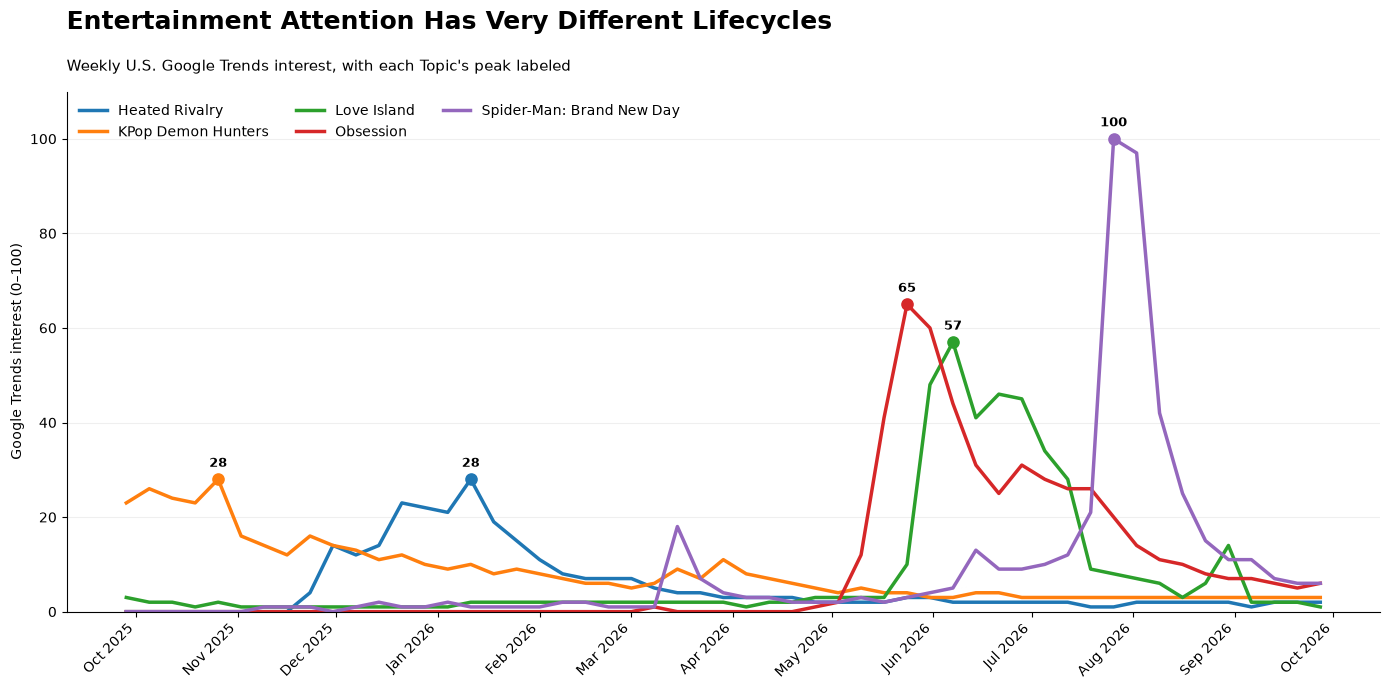

In [3]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

time_series["date"] = pd.to_datetime(time_series["date"])

fig, ax = plt.subplots(figsize=(14, 7))

for topic, group in time_series.groupby("topic_label"):
    group = group.sort_values("date")

    line, = ax.plot(
        group["date"],
        group["interest_index"],
        label=topic,
        linewidth=2.5
    )

    # Find peak
    peak = group.loc[group["interest_index"].idxmax()]

    # Use same color as the line
    ax.scatter(
        peak["date"],
        peak["interest_index"],
        s=65,
        color=line.get_color(),
        zorder=5
    )

    ax.annotate(
        f'{int(peak["interest_index"])}',
        (peak["date"], peak["interest_index"]),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )


# -------------------------
# Titles
# -------------------------

ax.set_title(
    "Entertainment Attention Has Very Different Lifecycles",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=45
)

ax.text(
    0,
    1.04,
    "Weekly U.S. Google Trends interest, with each Topic's peak labeled",
    transform=ax.transAxes,
    fontsize=11
)


# -------------------------
# Axes
# -------------------------

ax.set_xlabel("")
ax.set_ylabel("Google Trends interest (0–100)")
ax.set_ylim(0, 110)

# Show one date per month instead of every week
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)


# -------------------------
# Legend
# -------------------------

ax.legend(
    frameon=False,
    ncol=3,
    loc="upper left"
)


# -------------------------
# Styling
# -------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

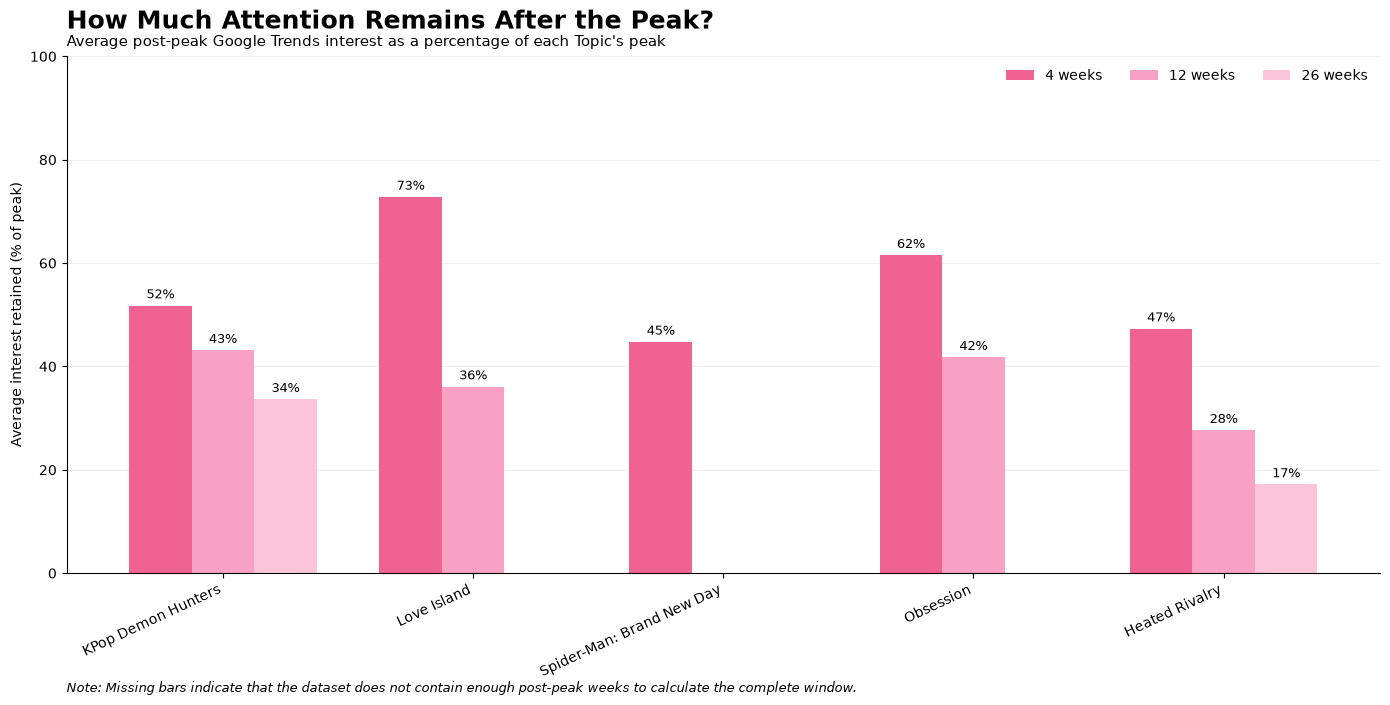

In [11]:
retention = features[
    [
        "topic_label",
        "global_max",
        "post_peak_mean_4",
        "post_peak_mean_12",
        "post_peak_mean_26"
    ]
].copy()

# Convert post-peak interest to % of each Topic's own peak
retention["4 weeks"] = (
    retention["post_peak_mean_4"] / retention["global_max"] * 100
)

retention["12 weeks"] = (
    retention["post_peak_mean_12"] / retention["global_max"] * 100
)

retention["26 weeks"] = (
    retention["post_peak_mean_26"] / retention["global_max"] * 100
)

retention = retention.set_index("topic_label")

# Plot only retention measures
ax = retention[
    ["4 weeks", "12 weeks", "26 weeks"]
].plot(
    kind="bar",
    figsize=(14, 7),
    width=0.75,
    color=["#F06292", "#F8A1C4", "#FBC4D8"]
)

ax.set_title(
    "How Much Attention Remains After the Peak?",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=20
)

ax.text(
    0,
    1.02,
    "Average post-peak Google Trends interest as a percentage of each Topic's peak",
    transform=ax.transAxes,
    fontsize=11
)

ax.set_ylabel("Average interest retained (% of peak)")
ax.set_xlabel("")

ax.set_ylim(0, 100)

ax.legend(
    title="",
    frameon=False,
    ncol=3
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.xticks(rotation=25, ha="right")

ax.text(
    0,
    -0.23,
    "Note: Missing bars indicate that the dataset does not contain enough post-peak weeks "
    "to calculate the complete window.",
    transform=ax.transAxes,
    fontsize=9,
    style="italic"
)

plt.subplots_adjust(bottom=0.25)

# Add labels only when the value actually exists
for container in ax.containers:
    labels = []

    for bar in container:
        height = bar.get_height()

        if pd.isna(height) or height == 0:
            labels.append("")
        else:
            labels.append(f"{height:.0f}%")

    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()